# Task 1: Linear Regression House Price Predictor

**Objective:** Build and evaluate a Linear Regression model for California house price prediction.

In this project, I followed a standard ML workflow:

- Loaded the California Housing data from a CSV upload when available, with a scikit-learn fallback
- Explored distributions, correlations, and missing values
- Prepared features for model training
- Trained a Linear Regression baseline model
- Evaluated the model using MAE, RMSE, and R2
- Visualized predictions and residuals
- Saved the trained model and generated a short PDF report


## 1. Setup

I started by importing the libraries needed for data analysis, visualization, model training, evaluation, and model saving.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

## 2. Load Dataset

This section supports both submission formats. If I upload a Kaggle/local California Housing CSV, the notebook uses that file. If no CSV is uploaded, it uses the scikit-learn California Housing dataset. The target is converted to `MedHouseVal` in $100,000 units for consistent evaluation.

In [2]:
# I keep this True so the notebook asks for a CSV first when uploads are available.
USE_CSV_UPLOAD = True

uploaded_df = None
csv_file_name = None

if USE_CSV_UPLOAD:
    try:
        from google.colab import files
        uploaded = files.upload()
        csv_files = [name for name in uploaded.keys() if name.lower().endswith('.csv')]
        if csv_files:
            csv_file_name = csv_files[0]
            uploaded_df = pd.read_csv(csv_file_name)
    except Exception:
        uploaded_df = None

if uploaded_df is not None:
    df = uploaded_df.copy()
    dataset_source = f'Uploaded CSV: {csv_file_name}'
    dataset_description = 'California housing data loaded from an uploaded CSV file.'

    column_map = {
        'longitude': 'Longitude',
        'latitude': 'Latitude',
        'housing_median_age': 'HouseAge',
        'total_rooms': 'TotalRooms',
        'total_bedrooms': 'TotalBedrooms',
        'population': 'Population',
        'households': 'Households',
        'median_income': 'MedInc',
        'median_house_value': 'MedHouseVal',
        'ocean_proximity': 'OceanProximity'
    }
    df = df.rename(columns={old: new for old, new in column_map.items() if old in df.columns})

    if 'MedHouseVal' in df.columns and df['MedHouseVal'].max() > 20:
        df['MedHouseVal'] = df['MedHouseVal'] / 100000

    numeric_columns = df.select_dtypes(include=np.number).columns
    df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

    if {'TotalRooms', 'Households'}.issubset(df.columns):
        df['AveRooms'] = df['TotalRooms'] / df['Households']
    if {'TotalBedrooms', 'Households'}.issubset(df.columns):
        df['AveBedrms'] = df['TotalBedrooms'] / df['Households']
    if {'Population', 'Households'}.issubset(df.columns):
        df['AveOccup'] = df['Population'] / df['Households']
    df = df.drop(columns=['TotalRooms', 'TotalBedrooms', 'Households'], errors='ignore')

    categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()
    if categorical_columns:
        df = pd.get_dummies(df, columns=categorical_columns, drop_first=True, dtype=int)
else:
    housing = fetch_california_housing(as_frame=True)
    df = housing.frame.copy()
    dataset_source = 'scikit-learn California Housing dataset'
    dataset_description = housing.DESCR

print('Dataset source:', dataset_source)
print('Rows, columns:', df.shape)
df.head()

Saving housing.csv to housing.csv
Dataset source: Uploaded CSV: housing.csv
Rows, columns: (20640, 13)


,Longitude,Latitude,HouseAge,Population,MedInc,MedHouseVal,AveRooms,AveBedrms,AveOccup,OceanProximity_INLAND,OceanProximity_ISLAND,OceanProximity_NEAR BAY,OceanProximity_NEAR OCEAN
0,-122.23,37.88,41.0,322.0,8.3252,4.526,6.984127,1.023810,2.555556,0,0,1,0
1,-122.22,37.86,21.0,2401.0,8.3014,3.585,6.238137,0.971880,2.109842,0,0,1,0
2,-122.24,37.85,52.0,496.0,7.2574,3.521,8.288136,1.073446,2.802260,0,0,1,0
3,-122.25,37.85,52.0,558.0,5.6431,3.413,5.817352,1.073059,2.547945,0,0,1,0
4,-122.25,37.85,52.0,565.0,3.8462,3.422,6.281853,1.081081,2.181467,0,0,1,0


In [3]:
print(dataset_description[:900])

California housing data loaded from an uploaded CSV file.


## 3. Exploratory Data Analysis

In [4]:
df.info()

missing_values = df.isnull().sum().sort_values(ascending=False)
print('\nMissing values by column:')
display(missing_values.to_frame('missing_count'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Longitude                  20640 non-null  float64
 1   Latitude                   20640 non-null  float64
 2   HouseAge                   20640 non-null  float64
 3   Population                 20640 non-null  float64
 4   MedInc                     20640 non-null  float64
 5   MedHouseVal                20640 non-null  float64
 6   AveRooms                   20640 non-null  float64
 7   AveBedrms                  20640 non-null  float64
 8   AveOccup                   20640 non-null  float64
 9   OceanProximity_INLAND      20640 non-null  int64  
 10  OceanProximity_ISLAND      20640 non-null  int64  
 11  OceanProximity_NEAR BAY    20640 non-null  int64  
 12  OceanProximity_NEAR OCEAN  20640 non-null  int64  
dtypes: float64(9), int64(4)
memory usage: 2.0 MB



,missing_count
Longitude,0
Latitude,0
HouseAge,0
Population,0
MedInc,0
MedHouseVal,0
AveRooms,0
AveBedrms,0
AveOccup,0
OceanProximity_INLAND,0


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.100910,0.519159,0.121204,1.005525,1.048860,1.100015,34.066667
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
OceanProximity_INLAND,20640.0,0.317393,0.465473,0.000000,0.000000,0.000000,1.000000,1.000000


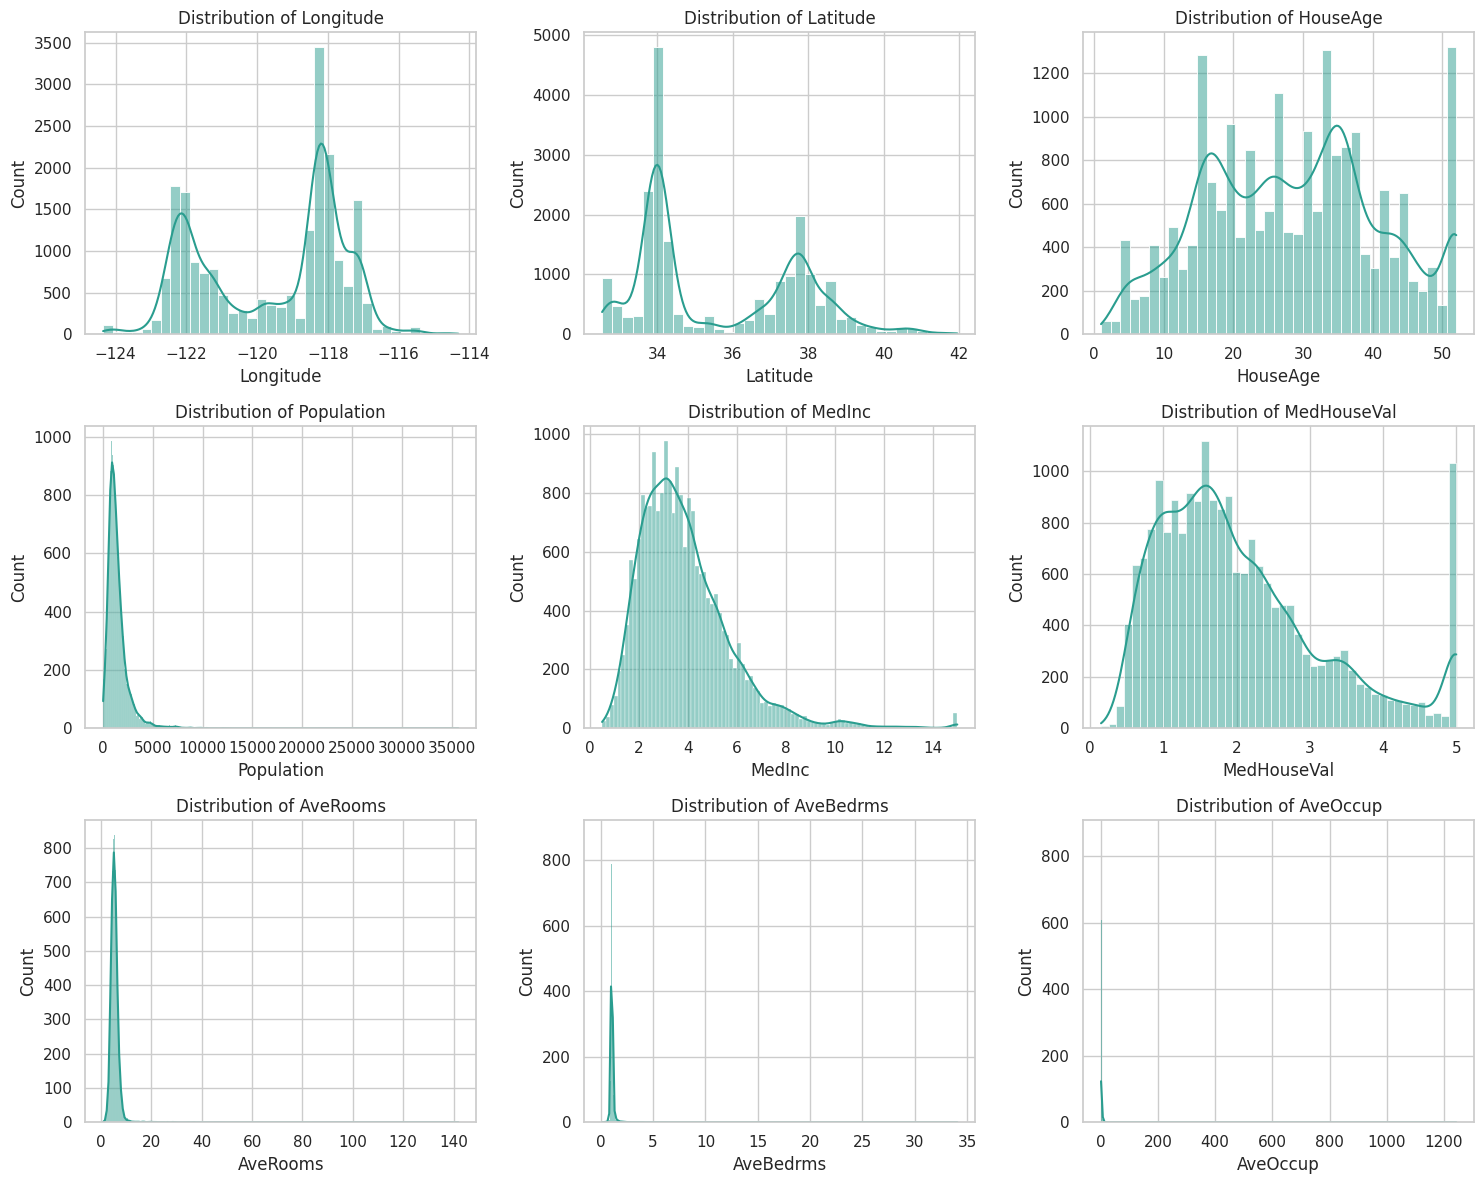

In [6]:
plot_columns = df.select_dtypes(include=np.number).columns[:9]
n_cols = 3
n_rows = int(np.ceil(len(plot_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).flatten()

for i, column in enumerate(plot_columns):
    sns.histplot(df[column], kde=True, ax=axes[i], color='#2a9d8f')
    axes[i].set_title(f'Distribution of {column}')

for j in range(len(plot_columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

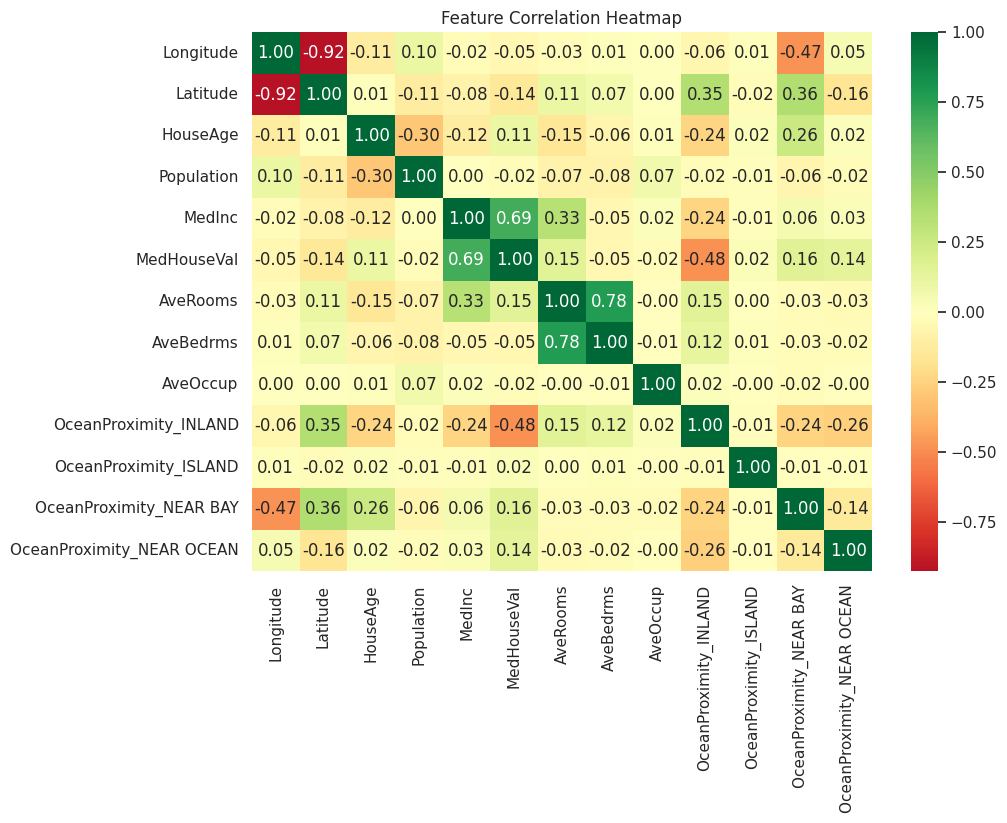

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
OceanProximity_NEAR BAY,0.160284
AveRooms,0.151948
OceanProximity_NEAR OCEAN,0.141862
HouseAge,0.105623
OceanProximity_ISLAND,0.023416
AveOccup,-0.023737
Population,-0.024650
AveBedrms,-0.045637


In [7]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

corr['MedHouseVal'].sort_values(ascending=False)

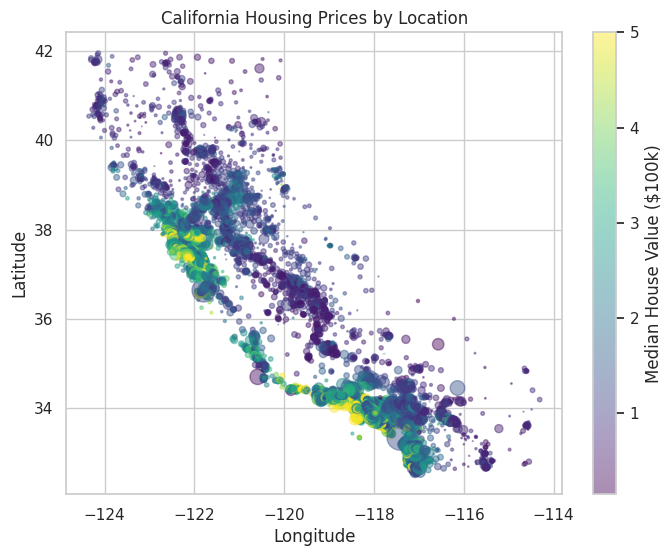

In [8]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df['Longitude'],
    df['Latitude'],
    c=df['MedHouseVal'],
    cmap='viridis',
    alpha=0.45,
    s=df['Population'] / 100
)
plt.colorbar(scatter, label='Median House Value ($100k)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices by Location')
plt.show()

### EDA Notes

My main observations from the exploratory analysis were:

- The dataset is mostly numeric and ready for regression after basic preprocessing.
- Missing numeric values, if present in the uploaded CSV, are filled with the median.
- `MedInc` has one of the strongest positive relationships with `MedHouseVal`.
- Location is important: higher values tend to appear around coastal and major metro areas.
- Some variables are skewed, so future versions could use transformations and feature engineering.

## 4. Train/Test Split

All numeric dataset features are used as inputs. The target is `MedHouseVal`.

In [9]:
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])
print('Features:', list(X.columns))

Training rows: 16512
Testing rows: 4128
Features: ['Longitude', 'Latitude', 'HouseAge', 'Population', 'MedInc', 'AveRooms', 'AveBedrms', 'AveOccup', 'OceanProximity_INLAND', 'OceanProximity_ISLAND', 'OceanProximity_NEAR BAY', 'OceanProximity_NEAR OCEAN']


## 5. Train Linear Regression Model

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Linear Regression model fitted on the training data.')

Linear Regression model fitted on the training data.


## 6. Evaluate Model

The target is measured in $100,000 units. For readability, this section also converts MAE and RMSE into approximate dollar values.

In [11]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Value': [mae, rmse, r2],
    'Interpretation': [
        f'Average absolute error: about ${mae * 100000:,.0f}',
        f'Typical larger-error penalty: about ${rmse * 100000:,.0f}',
        f'Model explains about {r2 * 100:.1f}% of test-set variance'
    ]
})

metrics

,Metric,Value,Interpretation
0,MAE,0.538797,"Average absolute error: about $53,880"
1,RMSE,0.812622,"Typical larger-error penalty: about $81,262"
2,R2 Score,0.496070,Model explains about 49.6% of test-set variance


In [12]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

coefficients

,Feature,Coefficient
9,OceanProximity_ISLAND,1.349178e+00
6,AveBedrms,6.618599e-01
4,MedInc,4.326793e-01
8,OceanProximity_INLAND,-3.745925e-01
0,Longitude,-2.690535e-01
1,Latitude,-2.496060e-01
5,AveRooms,-1.022168e-01
11,OceanProximity_NEAR OCEAN,8.092854e-02
10,OceanProximity_NEAR BAY,2.971721e-02
2,HouseAge,8.719490e-03


## 7. Prediction Plots

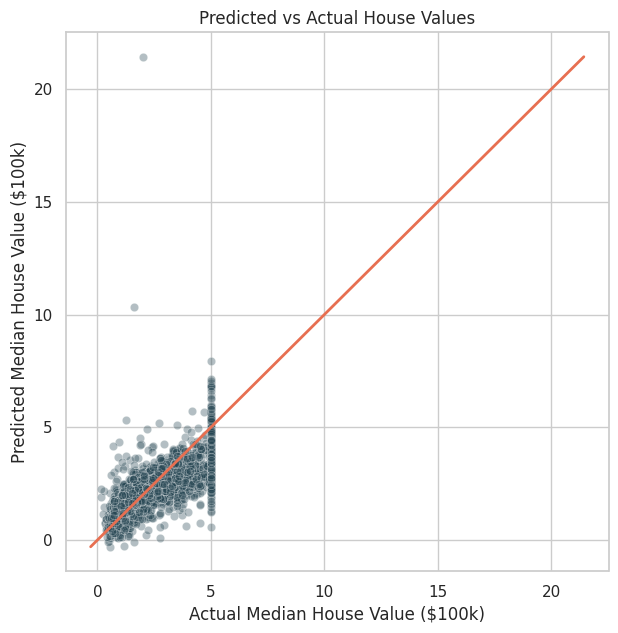

In [13]:
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.35, color='#264653')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='#e76f51', linewidth=2)
plt.xlabel('Actual Median House Value ($100k)')
plt.ylabel('Predicted Median House Value ($100k)')
plt.title('Predicted vs Actual House Values')
plt.show()

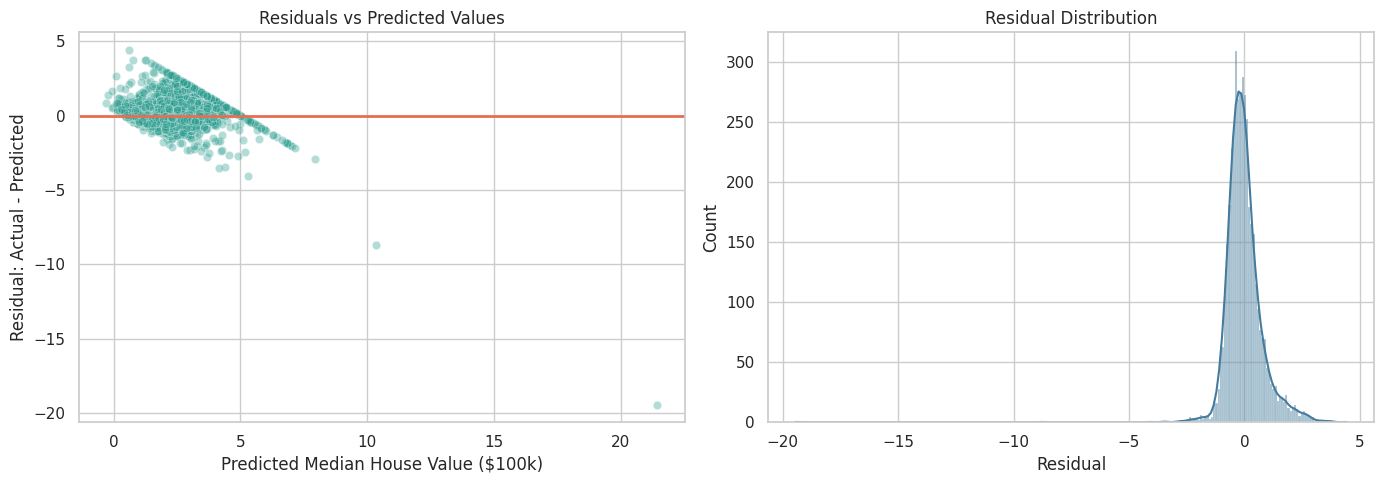

In [14]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_pred, y=residuals, alpha=0.35, color='#2a9d8f', ax=axes[0])
axes[0].axhline(0, color='#e76f51', linewidth=2)
axes[0].set_xlabel('Predicted Median House Value ($100k)')
axes[0].set_ylabel('Residual: Actual - Predicted')
axes[0].set_title('Residuals vs Predicted Values')

sns.histplot(residuals, kde=True, color='#457b9d', ax=axes[1])
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

## 8. Save Model and Predict New Inputs

In [15]:
model_path = 'california_linear_regression_model.pkl'
joblib.dump(model, model_path)
print(f'Saved model to {model_path}')

def predict_house_value(med_inc, house_age, ave_rooms, ave_bedrms, population, ave_occup, latitude, longitude):
    sample = pd.DataFrame(0, index=[0], columns=X.columns)
    values = {
        'MedInc': med_inc,
        'HouseAge': house_age,
        'AveRooms': ave_rooms,
        'AveBedrms': ave_bedrms,
        'Population': population,
        'AveOccup': ave_occup,
        'Latitude': latitude,
        'Longitude': longitude
    }
    for feature, value in values.items():
        if feature in sample.columns:
            sample.loc[0, feature] = value

    prediction = model.predict(sample)[0]
    return prediction, prediction * 100000

example_prediction, example_dollars = predict_house_value(
    med_inc=5.0,
    house_age=25,
    ave_rooms=5.2,
    ave_bedrms=1.1,
    population=1200,
    ave_occup=3.0,
    latitude=34.05,
    longitude=-118.25
)

print(f'Example prediction: {example_prediction:.3f} units, or about ${example_dollars:,.0f}')

Saved model to california_linear_regression_model.pkl
Example prediction: 2.695 units, or about $269,543


## 9. Final Conclusion

This project demonstrates the complete beginner-friendly ML lifecycle: data loading, EDA, preprocessing, model training, evaluation, model saving, and reporting. Linear Regression is a good interpretable baseline, but stronger results are likely possible with feature engineering and nonlinear models.